<div align="center">

# Medical Document Classification

</div>

This notebook builds baseline NLP classification models for organizing medical documents into structured categories. Using TF-IDF vectorization and classical machine learning algorithms, it establishes benchmark performance for document classification. These results serve as a foundation for future deep learning models and real-world deployment in a medical document management desktop application.

## Importing the dataset:

In [2]:
import pandas as pd

path = '/kaggle/input/medical-document-ocr-text-dataset/medical_documents_dataset.csv'
data = pd.read_csv(path)
data.head()

,ocr_lines,text,file_format,label
0,"['Apollo Hospital', 'Prescription', 'Patient N...",Apollo Hospital Prescription Patient Name: Roh...,png,prescription
1,"['Fortis Healthcare', 'Prescription', 'Patient...",Fortis Healthcare Prescription Patient Name: A...,jpg,prescription
2,"['Max Healthcare', 'Prescription', 'Patient Na...",Max Healthcare Prescription Patient Name: Neha...,pdf,prescription
3,"['Manipal Hospital', 'Prescription', 'Patient ...",Manipal Hospital Prescription Patient Name: Ne...,png,prescription
4,"['Fortis Healthcare', 'Prescription', 'Patient...",Fortis Healthcare Prescription Patient Name: S...,png,prescription


In [3]:
#exploring the dataset
data.info()

#looking for null values
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16500 entries, 0 to 16499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ocr_lines    16500 non-null  object
 1   text         16500 non-null  object
 2   file_format  16500 non-null  object
 3   label        16500 non-null  object
dtypes: object(4)
memory usage: 515.8+ KB


ocr_lines      0
text           0
file_format    0
label          0
dtype: int64

* Our data consists of 16500 total document samples.
* There are no null values present which is a good thing.
* All the columns are in object dtype.  

In [4]:
#seperating target and features
X = data.drop("label", axis=1)
y = data['label']

## EDA (Exploratory Data Analysis):
Since we now know that our data has no null values, its time to explore the data more closely

### Cheking for target imbalance:

Counter({'prescription': 1500, 'lab_report': 1500, 'scan_report': 1500, 'discharge_summary': 1500, 'medical_bill': 1500, 'insurance_claim': 1500, 'insurance_policy': 1500, 'medical_history': 1500, 'referral_letter': 1500, 'id_proof': 1500, 'other': 1500})


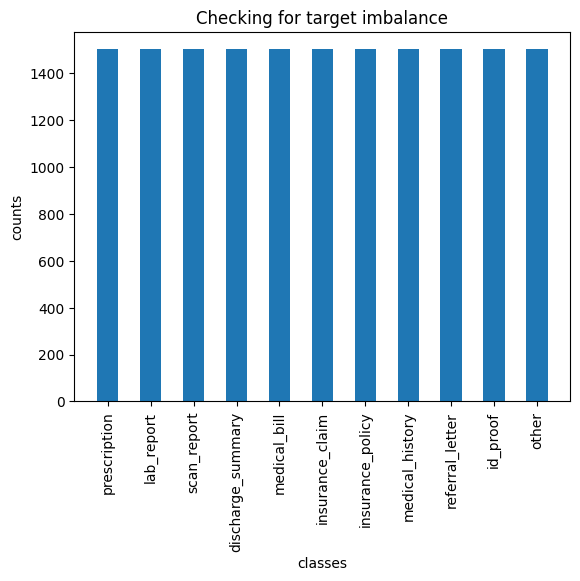

In [5]:
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter(y)

print(counts)

plt.bar(counts.keys(), counts.values(), width=0.5, align='center')
plt.xticks(rotation=90)
plt.xlabel('classes')
plt.ylabel('counts')
plt.title('Checking for target imbalance')
plt.show()

All the classes available have equal number of samples, i.e. theres no class imbalance

### Feature distribution:

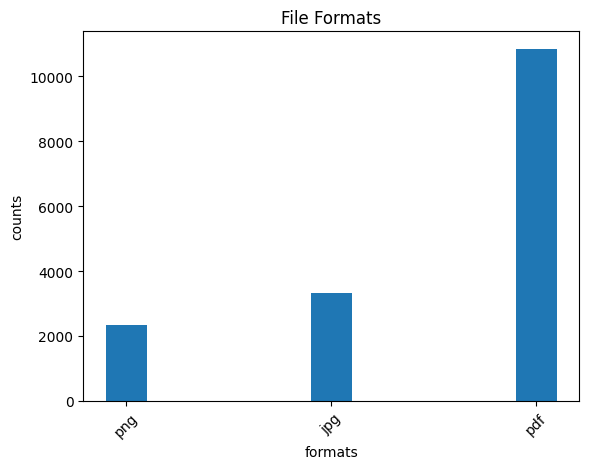

In [6]:
counts = Counter(X['file_format'])

plt.bar(counts.keys(), counts.values(), width=0.2, align='center')
plt.xticks(rotation=45)
plt.xlabel('formats')
plt.ylabel('counts')
plt.title('File Formats')
plt.show()

Clearly the samples with file_format of 'pdf' are more as compared to that of 'png' and 'jpg'.

Next our ocr_lines column is in string format but as the dataset discription suggests that its a list where each sample in the list is a line from the document, so we'll have to covert the str format lists to list by removing " ":
* Right now: "['Apollo Hospital', 'Prescription', ...]"
* After a few lines of code: ['Apollo Hospital', 'Prescription', ...]

In [7]:
import ast

X['ocr_lines'] = X['ocr_lines'].apply(ast.literal_eval) #removing " "
print(len(X['ocr_lines'][0])) 

26


The above output is number of lines in the first sample document, similarly we can find num of lines for each of the sample document and bucketize them to visualize it.

In [8]:
X['line_count'] = X['ocr_lines'].map(lambda x: len(x))
X.head()

,ocr_lines,text,file_format,line_count
0,"[Apollo Hospital, Prescription, Patient Name: ...",Apollo Hospital Prescription Patient Name: Roh...,png,26
1,"[Fortis Healthcare, Prescription, Patient Name...",Fortis Healthcare Prescription Patient Name: A...,jpg,19
2,"[Max Healthcare, Prescription, Patient Name: N...",Max Healthcare Prescription Patient Name: Neha...,pdf,26
3,"[Manipal Hospital, Prescription, Patient Name:...",Manipal Hospital Prescription Patient Name: Ne...,png,27
4,"[Fortis Healthcare, Prescription, Patient Name...",Fortis Healthcare Prescription Patient Name: S...,png,19


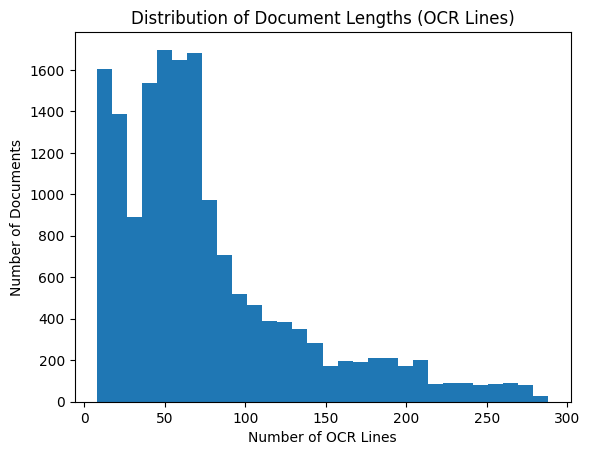

In [9]:
plt.figure()
plt.hist(X['line_count'], bins=30)
plt.title("Distribution of Document Lengths (OCR Lines)")
plt.xlabel("Number of OCR Lines")
plt.ylabel("Number of Documents")
plt.show()

Better visualized in 3 buckets:

Counter({Interval(7.72, 101.333, closed='right'): 12641, Interval(101.333, 194.667, closed='right'): 2859, Interval(194.667, 288.0, closed='right'): 1000})


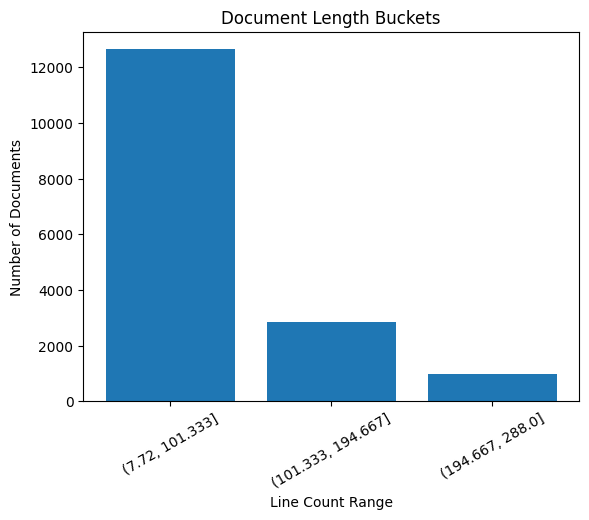

In [10]:
buckets = pd.cut(X['line_count'], bins=3)
bucket_counts = Counter(buckets)

print(bucket_counts)

labels = [str(interval) for interval in bucket_counts.keys()]
values = list(bucket_counts.values())

plt.figure()
plt.bar(labels, values)
plt.title("Document Length Buckets")
plt.xlabel("Line Count Range")
plt.ylabel("Number of Documents")
plt.xticks(rotation=30)
plt.show()

These could add value while predicting:
* Interval(7.72, 101.333, closed='right'): 12641,
* Interval(101.333, 194.667, closed='right'): 2859,
* Interval(194.667, 288.0, closed='right'): 1000

### WordCloud:
To see which words appear most frequently in training data.

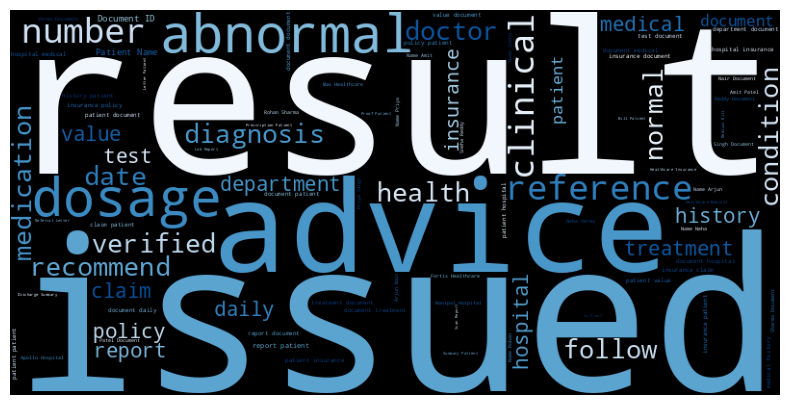

In [11]:
from wordcloud import WordCloud

text = " ".join(X['text'])

wc = WordCloud(height=400, 
               width=800, 
               random_state=42,
               background_color='black',
               colormap='Blues'
              ).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.show()

most frequent words are plotted in large fonts and smaller ones are less frequent. This tells us about the words that are more important than others.

### Word Counts:

Counter({'pdf': 10840, 'jpg': 3315, 'png': 2345})


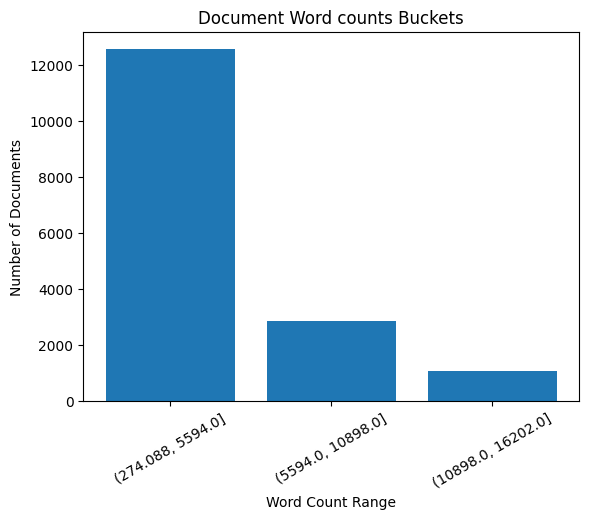

In [12]:
X['word_count'] = X['text'].map(lambda x: len(x))
buckets = pd.cut(X['word_count'], bins=3)
bucket_counts = Counter(buckets)

print(counts)

labels = [str(key) for key in bucket_counts.keys()]
values = list(bucket_counts.values())

plt.figure()
plt.bar(labels, values)
plt.title("Document Word counts Buckets")
plt.xlabel("Word Count Range")
plt.ylabel("Number of Documents")
plt.xticks(rotation=30)
plt.show()

## Train/Validation split:

In [13]:
#Encoding teh labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y_encoded, 
                                                  stratify=y, 
                                                  test_size=0.2,
                                                  random_state=42)

## Preprocessing Pipeline:

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

#common transformer
preprocessor = ColumnTransformer(
    transformers=[
                ('text',
                 TfidfVectorizer(
                     max_features=10000,
                     ngram_range=(1,2),  #bigrams
                     min_df=2,  #removes rare words
                     max_df=0.95  #removes overly common words
                 ),'text'),
                ('counts',StandardScaler(),['line_count','word_count']),
                ('file_format',OneHotEncoder(handle_unknown='ignore'),['file_format'])
    ],
    remainder='drop',     
)

#transformer for naive-bayes
nb_preprocessor = ColumnTransformer(
    transformers=[
        ('text',
         TfidfVectorizer(
             max_features=5000,
             ngram_range=(1,2),
             min_df=2,
             max_df=0.95
         ),'text')
    ],
    remainder='drop',
)

## Baseline Models:
Here we'll be trying 4 models to see which gives the best baseline results, and then proceed hypertuning the best performing.
The models being considered are:
* SVM
* LogisticRegression
* NaiveBayes
* XGBClassifier

In [17]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import ComplementNB


#SVM
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced'
)

#LogReg
logreg_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    n_jobs=-1
)

#XGB
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1
)

#Naive-Bayes
nb_model = ComplementNB()

### Final Pipelines:

In [19]:
from sklearn.pipeline import Pipeline

#svm pipeline
svm_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', svm_model)
])

#logreg pipeline
logreg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', logreg_model)
])

#xgboost piepline
xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', xgb_model)
])

#naive-bayes pipeline
nb_pipeline = Pipeline([
    ('prep', nb_preprocessor),
    ('model', nb_model)
])

## Fitting and Testing:
1. Training all the model on train data:

In [20]:
svm_pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=10000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text'),
                                                 ('counts', StandardScaler(),
                                                  ['line_count', 'word_count']),
                                                 ('file_format',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['file_format'])])),
                ('model', LinearSVC(class_weight='balanced'))])

In [22]:
logreg_pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=10000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text'),
                                                 ('counts', StandardScaler(),
                                                  ['line_count', 'word_count']),
                                                 ('file_format',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['file_format'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1))])

In [23]:
nb_pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=5000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text')])),
                ('model', ComplementNB())])

In [24]:
xgb_pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=10000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'text'),
                                                 ('counts', StandardScaler(),
                                                  ['line_count', 'word_count']),
                                                 ('file_format',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['file_format'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

2. Evaluating on validation set accuracy: 

In [25]:
y_pred_svm = svm_pipeline.predict(X_val)
y_pred_logreg = logreg_pipeline.predict(X_val)
y_pred_xgb = xgb_pipeline.predict(X_val)
y_pred_nb = nb_pipeline.predict(X_val)

In [26]:
from sklearn.metrics import accuracy_score

print(f"Validation_accuracy_svm:{accuracy_score(y_val,y_pred_svm)}")
print(f"Validation_accuracy_logreg:{accuracy_score(y_val,y_pred_logreg)}")
print(f"Validation_accuracy_xgb:{accuracy_score(y_val,y_pred_xgb)}")
print(f"Validation_accuracy_nb:{accuracy_score(y_val,y_pred_nb)}")

Validation_accuracy_svm:0.9824242424242424
Validation_accuracy_logreg:0.9581818181818181
Validation_accuracy_xgb:0.9981818181818182
Validation_accuracy_nb:0.9142424242424242


These validation score are astronomical.

Future Chnages:
* Creating a synthetic test file to evaluate models on.

Hope the dataset and this notebook will be helpful.